In [1]:
import scanpy as sc
adata = sc.read_h5ad("F4_VisiumHD.h5ad")  # full load
# or: adata = sc.read_h5ad("combinedHD_8um_v2.h5ad", backed="r")

In [2]:
mapping = {"Assembloid": "A55", "VIO": "V10"}  # ensure '0' vs 'O' is correct
adata.obs["library_id"] = adata.obs["sample"].astype(str).map(mapping).astype("category")
adA55 = adata[adata.obs['library_id'] == 'A55'].copy()
adV10 = adata[adata.obs['library_id'] == 'V10'].copy()


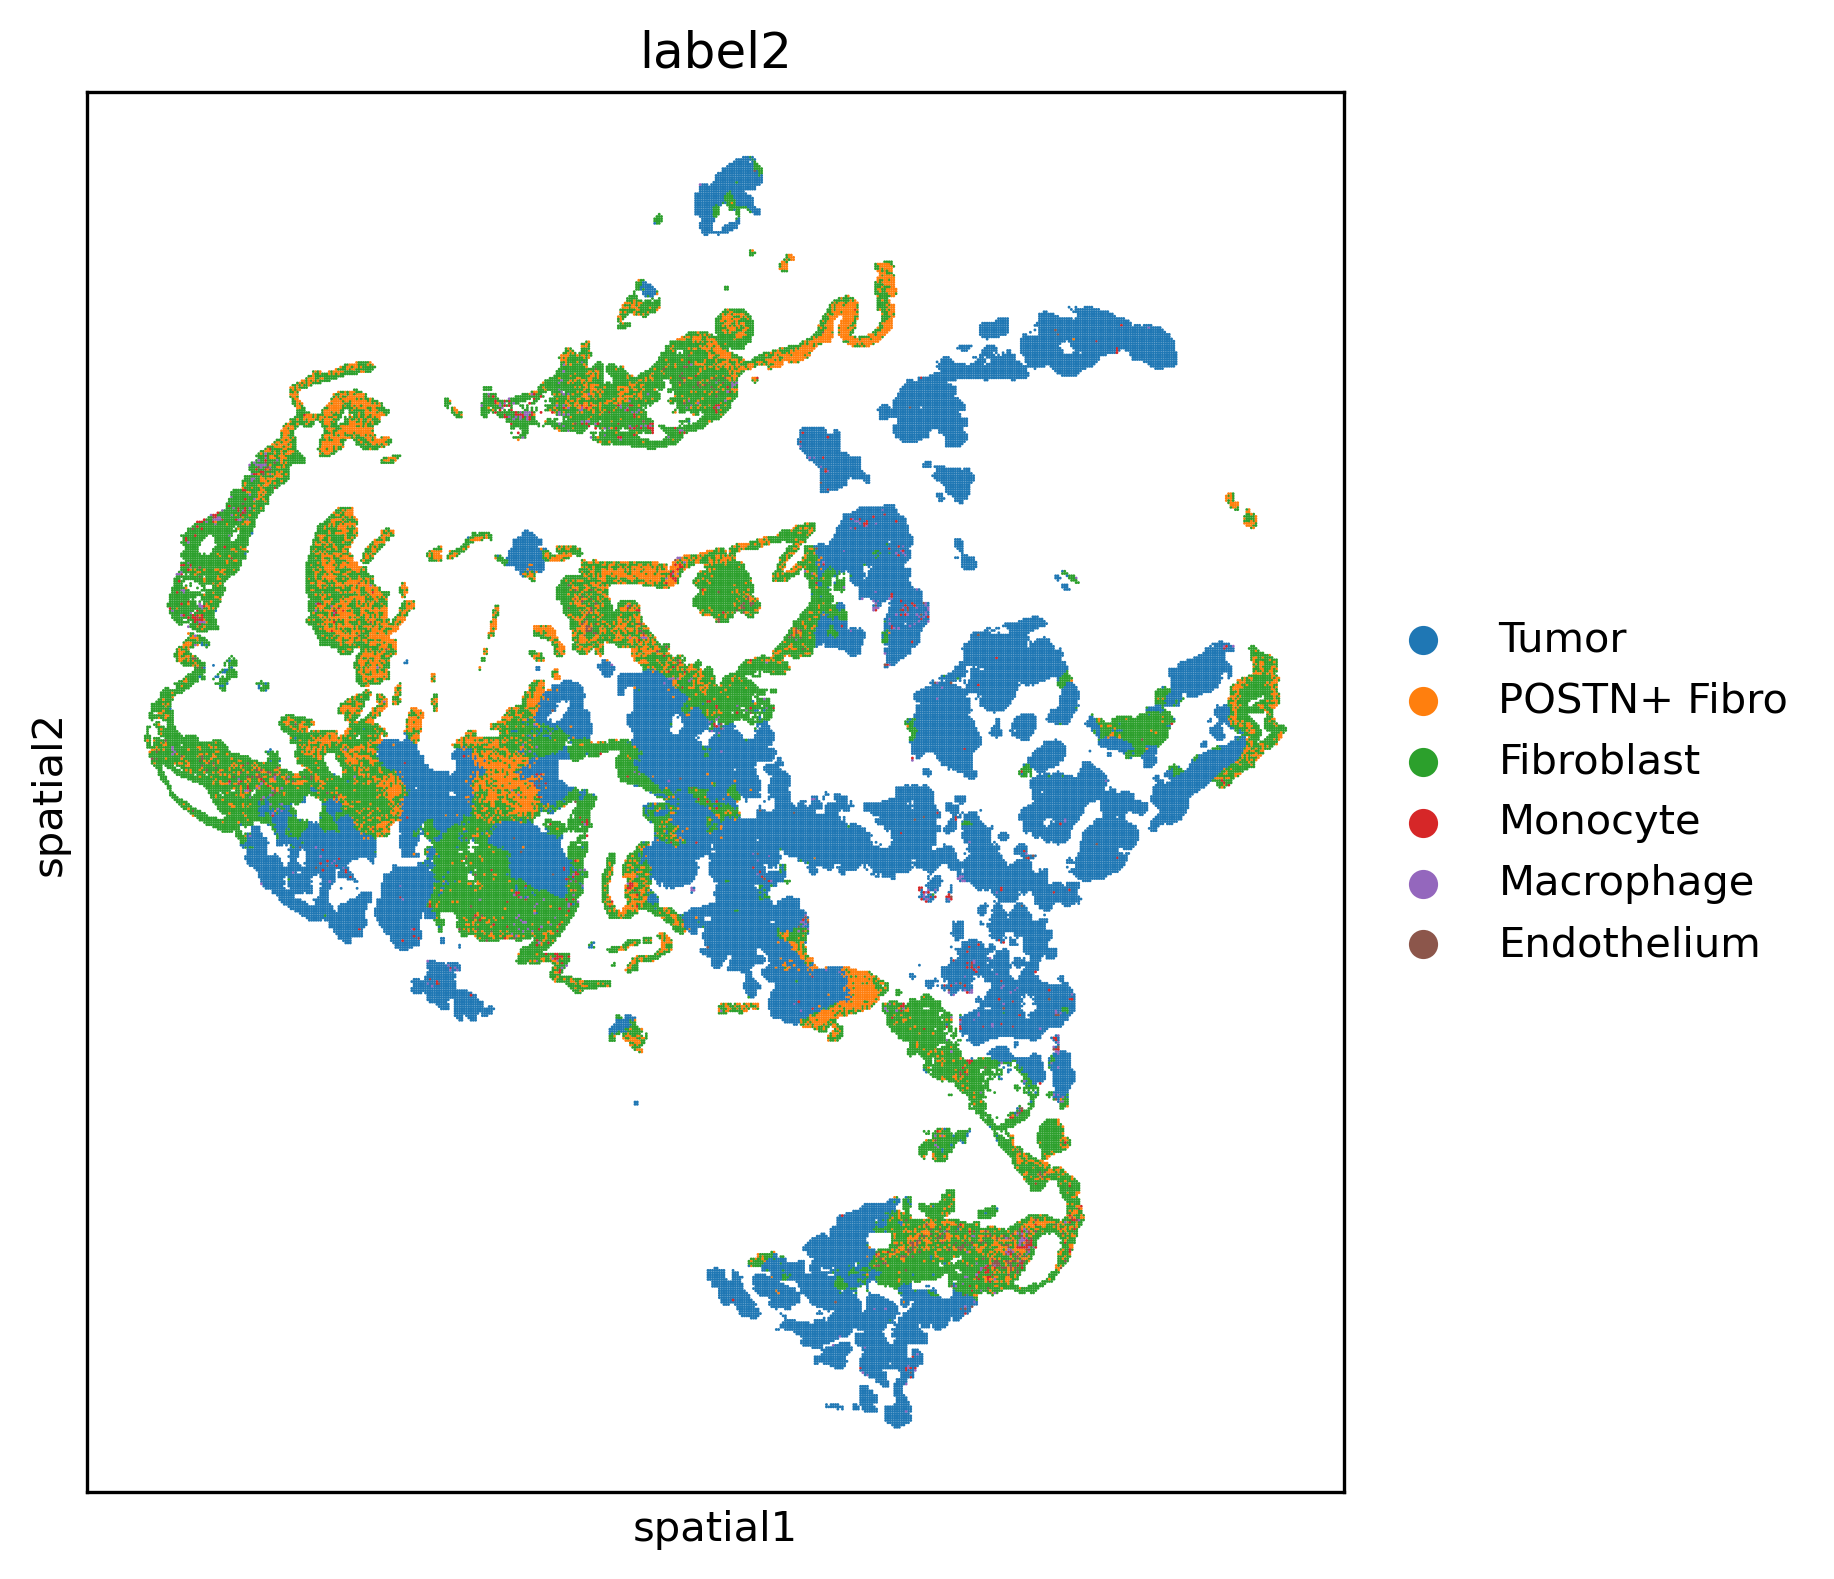

In [3]:
# Figure 4a
import squidpy as sq
sq.pl.spatial_scatter(
    adA55,
    color="label2",          # use the categorical key
    library_key="library_id",
    library_id=["A55"],
    img=False,
    alpha=1.0,  
    outline=False,
    size=1.25,
    figsize=(6, 6),
    dpi=300,                 # high-res canvas
)  # [web:1]

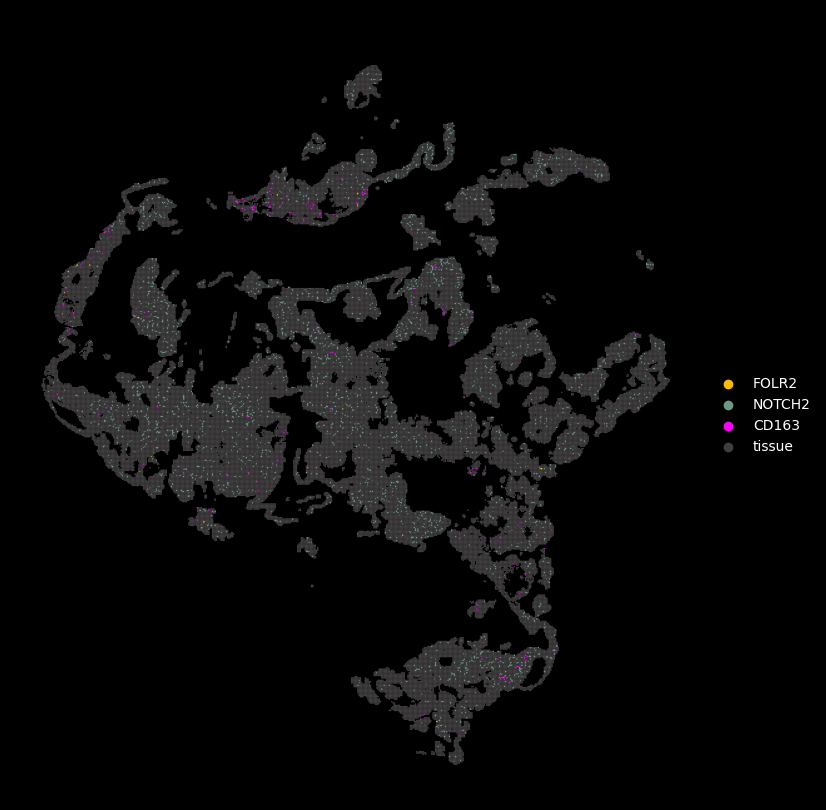

In [4]:
import matplotlib.pyplot as plt
import squidpy as sq
import pandas as pd
import numpy as np

# Define your gene list and corresponding thresholds once
genes = ['FOLR2', 'NOTCH2','CD163']
thresholds = [0.1, 0.1,0.1]

# 1) Define expression dataframe
expr = adA55.to_df()[genes]

# 2) Define conditions and choices in exact priority order (Priority 1 first)
conditions = [expr[gene] > thresh for gene, thresh in zip(genes, thresholds)]
choices = genes

# 3) Apply hierarchy; default to "tissue" if no conditions are met
adA55.obs["label_markers"] = pd.Categorical(np.select(conditions, choices, default="tissue"), categories=choices + ["tissue"])

# 4) Assign 4 colors corresponding to the genes + 1 tissue background
adA55.uns["label_markers_colors"] = ['#fcba03',  '#6d9987','Magenta', '#403e3f']

# 5) Visualization with compressed parameters
fig, ax = plt.subplots(facecolor="black", figsize=(10, 10)); ax.set_facecolor("black")
sq.pl.spatial_scatter(adA55, color="label_markers", library_key="library_id", library_id=["A55"], 
                      img=False, alpha=1.0, outline=False, size=1.3, fig=fig, ax=ax, frameon=False, 
                      legend_fontsize="medium", legend_fontweight="bold", legend_fontoutline=2)

# 6) Style legend for dark mode
leg = ax.get_legend()
if leg:
    for txt in leg.get_texts(): txt.set_color("white")
    if leg.get_title(): leg.get_title().set_color("white")
    leg.get_frame().set_facecolor("black"); leg.get_frame().set_edgecolor("white")

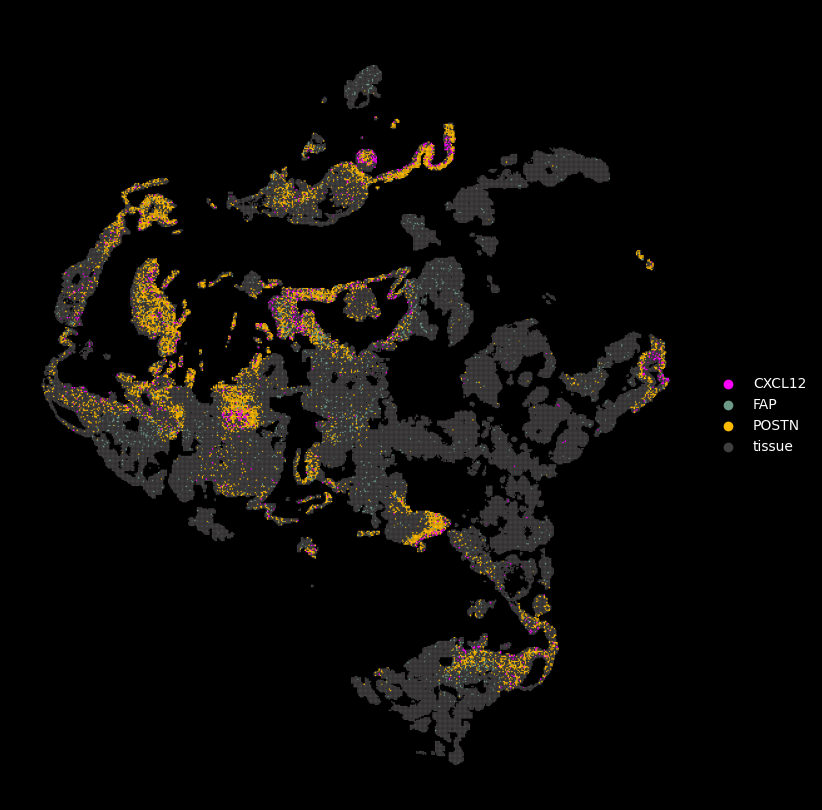

In [5]:
import matplotlib.pyplot as plt
import squidpy as sq
import pandas as pd
import numpy as np

# Define your gene list and corresponding thresholds once
genes = ['CXCL12', 'FAP', 'POSTN']
thresholds = [0.1, 0.1, 0.1]

# 1) Define expression dataframe
expr = adA55.to_df()[genes]

# 2) Define conditions and choices in exact priority order (Priority 1 first)
conditions = [expr[gene] > thresh for gene, thresh in zip(genes, thresholds)]
choices = genes

# 3) Apply hierarchy; default to "tissue" if no conditions are met
adA55.obs["label_markers"] = pd.Categorical(np.select(conditions, choices, default="tissue"), categories=choices + ["tissue"])

# 4) Assign 4 colors corresponding to the genes + 1 tissue background
adA55.uns["label_markers_colors"] = [ 'Magenta', '#6d9987','#fcba03','#403e3f']

# 5) Visualization with compressed parameters
fig, ax = plt.subplots(facecolor="black", figsize=(10, 10)); ax.set_facecolor("black")
sq.pl.spatial_scatter(adA55, color="label_markers", library_key="library_id", library_id=["A55"], 
                      img=False, alpha=1.0, outline=False, size=1.3, fig=fig, ax=ax, frameon=False, 
                      legend_fontsize="medium", legend_fontweight="bold", legend_fontoutline=2)

# 6) Style legend for dark mode
leg = ax.get_legend()
if leg:
    for txt in leg.get_texts(): txt.set_color("white")
    if leg.get_title(): leg.get_title().set_color("white")
    leg.get_frame().set_facecolor("black"); leg.get_frame().set_edgecolor("white")

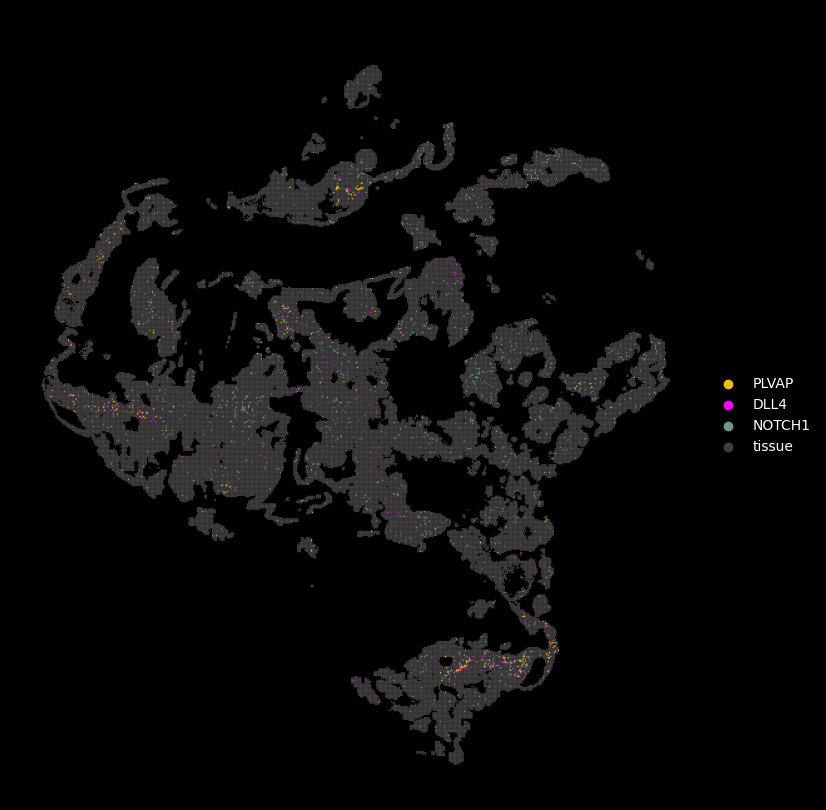

In [6]:
import matplotlib.pyplot as plt
import squidpy as sq
import pandas as pd
import numpy as np

# Define your gene list and corresponding thresholds once
genes = ['PLVAP', 'DLL4', 'NOTCH1']
thresholds = [0.1, 0.1, 0.1]

# 1) Define expression dataframe
expr = adA55.to_df()[genes]

# 2) Define conditions and choices in exact priority order (Priority 1 first)
conditions = [expr[gene] > thresh for gene, thresh in zip(genes, thresholds)]
choices = genes

# 3) Apply hierarchy; default to "tissue" if no conditions are met
adA55.obs["label_markers"] = pd.Categorical(np.select(conditions, choices, default="tissue"), categories=choices + ["tissue"])

# 4) Assign 4 colors corresponding to the genes + 1 tissue background
adA55.uns["label_markers_colors"] = ['#fcba03', 'Magenta', '#6d9987','#403e3f']
# yellow, Magenta, green

# 5) Visualization with compressed parameters
fig, ax = plt.subplots(facecolor="black", figsize=(10, 10)); ax.set_facecolor("black")
sq.pl.spatial_scatter(adA55, color="label_markers", library_key="library_id", library_id=["A55"], 
                      img=False, alpha=1.0, outline=False, size=1.3, fig=fig, ax=ax, frameon=False, 
                      legend_fontsize="medium", legend_fontweight="bold", legend_fontoutline=2)

# 6) Style legend for dark mode
leg = ax.get_legend()
if leg:
    for txt in leg.get_texts(): txt.set_color("white")
    if leg.get_title(): leg.get_title().set_color("white")
    leg.get_frame().set_facecolor("black"); leg.get_frame().set_edgecolor("white")

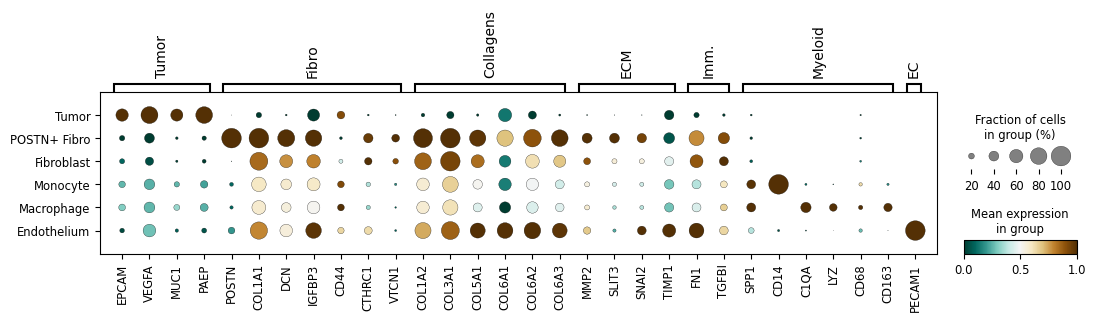

In [7]:
import scanpy as sc

# Supplementary
epithelium_genes_grouped = {
    'Tumor': ['EPCAM', 'VEGFA', 'MUC1', 'PAEP'],
    'Fibro': ['POSTN','COL1A1', 'DCN', 'IGFBP3', 'CD44', 'CTHRC1', 'VTCN1'],
    'Collagens': ['COL1A2', 'COL3A1', 'COL5A1', 'COL6A1', 'COL6A2', 'COL6A3'],
    'ECM': ['MMP2', 'SLIT3', 'SNAI2', 'TIMP1'],
    'Imm.': ['FN1', 'TGFBI'],
    'Myeloid': ['SPP1', 'CD14', 'C1QA', 'LYZ', 'CD68', 'CD163'],
    'EC':['PECAM1']
}

sc.pl.dotplot(
    adA55, 
    var_names=epithelium_genes_grouped, 
    groupby='label2', 
    standard_scale='var',
    cmap='BrBG_r',
    colorbar_title='Mean expression\nin group'
)

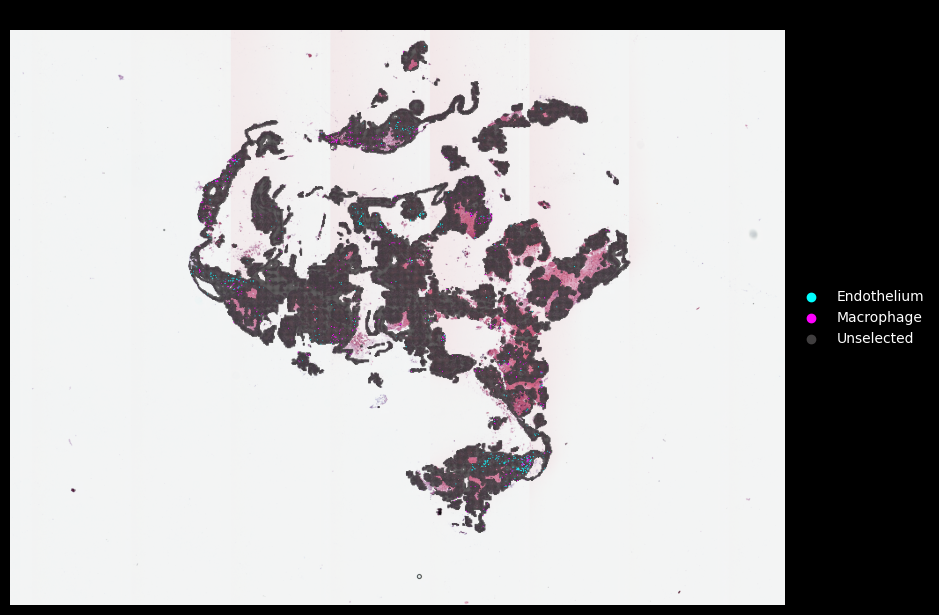

In [8]:
import matplotlib.pyplot as plt
import squidpy as sq
import numpy as np
import pandas as pd

# 1. Create the new column with filtered identities
target_cells = ["Endothelium", "Macrophage"]
adata.obs["label_viz"] = pd.Categorical(
    np.where(adata.obs["label2"].isin(target_cells), adata.obs["label2"].astype(str), "Unselected"),
    categories=["Endothelium", "Macrophage", "Unselected"]
)

# 2. Assign specific colors (Endothelium=cyan, Macrophage=magenta, Unselected=black)
adata.uns["label_viz_colors"] = ["cyan", "magenta", "#403e3f"]

# 3. Setup black background figure
fig, ax = plt.subplots(facecolor="black", figsize=(10, 10))
ax.set_facecolor("black")

# 4. Plot using the new column
sq.pl.spatial_scatter(
    adata,
    color="label_viz",
    library_key="library_id",
    library_id=["A55"],
    img=True,                # H&E visible
    img_alpha=1,
    alpha=1.0,
    size=1.3,
    fig=fig,
    ax=ax,
    frameon=False,
    legend_fontsize="medium",
    legend_fontweight="bold",
    legend_fontoutline=2,
)

# 5. Style the legend
leg = ax.get_legend()
if leg is not None:
    for txt in leg.get_texts():
        txt.set_color("white")
    leg.get_frame().set_facecolor("black")
    leg.get_frame().set_edgecolor("white")

plt.show()